# Time Series Forecasting with ARIMA

<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2022/06/Time-Series-Forecasting-with-ARIMA-using-Python.png?resize=1200%2C675&ssl=1"/>

In [2]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta

In [3]:
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2

data = yf.download('GOOG', 
                      start=start_date, 
                      end=end_date, 
                      progress=False)

In [4]:
data["Date"] = data.index
data = data[["Date", "Open", "High", "Low", "Close", "Volume"]]
data.reset_index(drop=True, inplace=True)
print(data.head())

Price        Date        Open        High         Low       Close    Volume
Ticker                   GOOG        GOOG        GOOG        GOOG      GOOG
0      2025-04-21  150.444878  150.539552  147.888712  149.343689  16147800
1      2025-04-22  150.549545  154.077342  150.350222  153.369781  15910300
2      2025-04-23  157.365968  159.468700  155.811345  157.176620  18575700
3      2025-04-24  157.978835  161.152875  157.545336  160.913696  30787500
4      2025-04-25  166.524310  167.660382  162.438430  163.285507  35148100


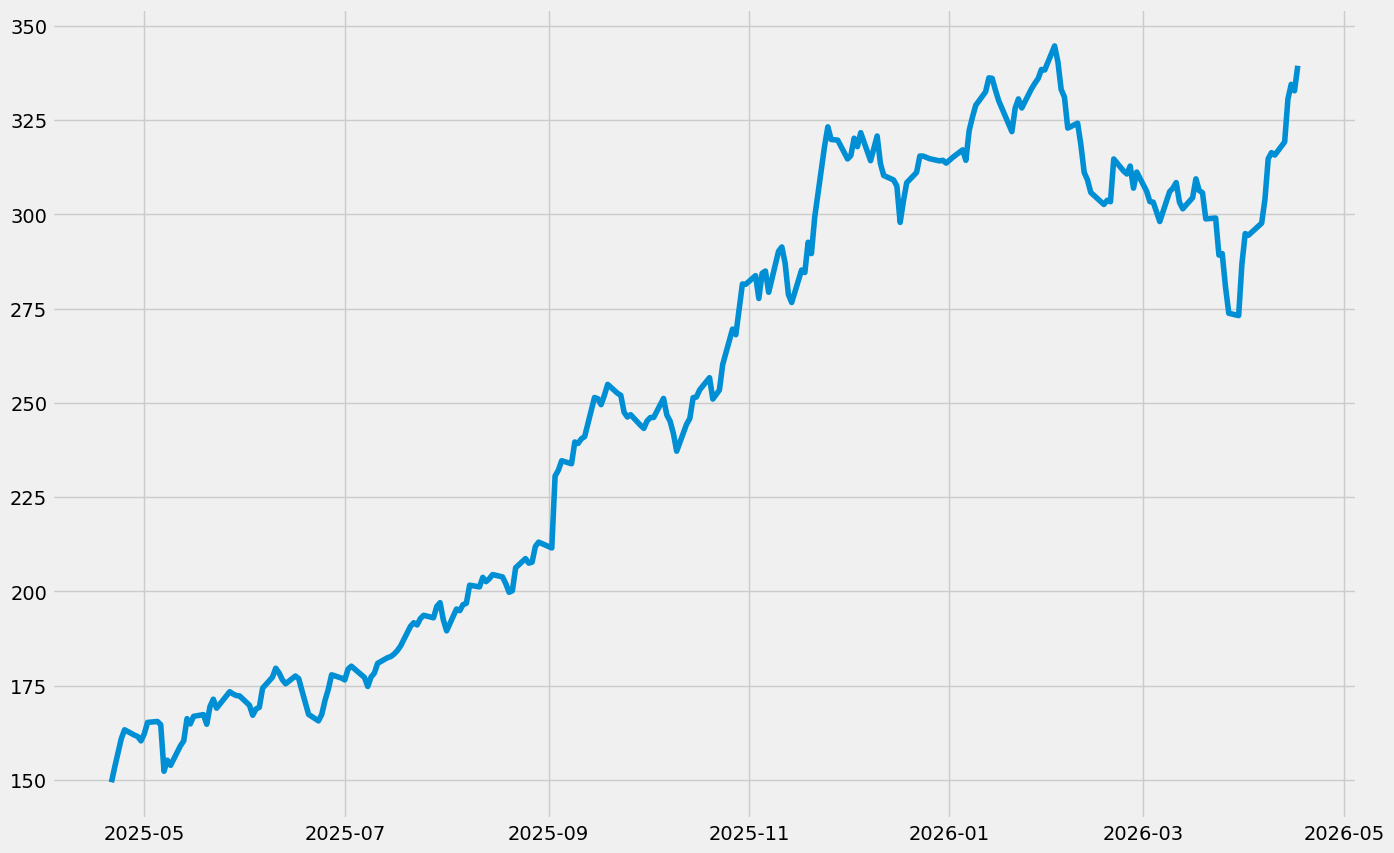

In [5]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15, 10))
plt.plot(data["Date"], data["Close"])

## Using ARIMA for Time Series Forecasting

<Figure size 640x480 with 0 Axes>

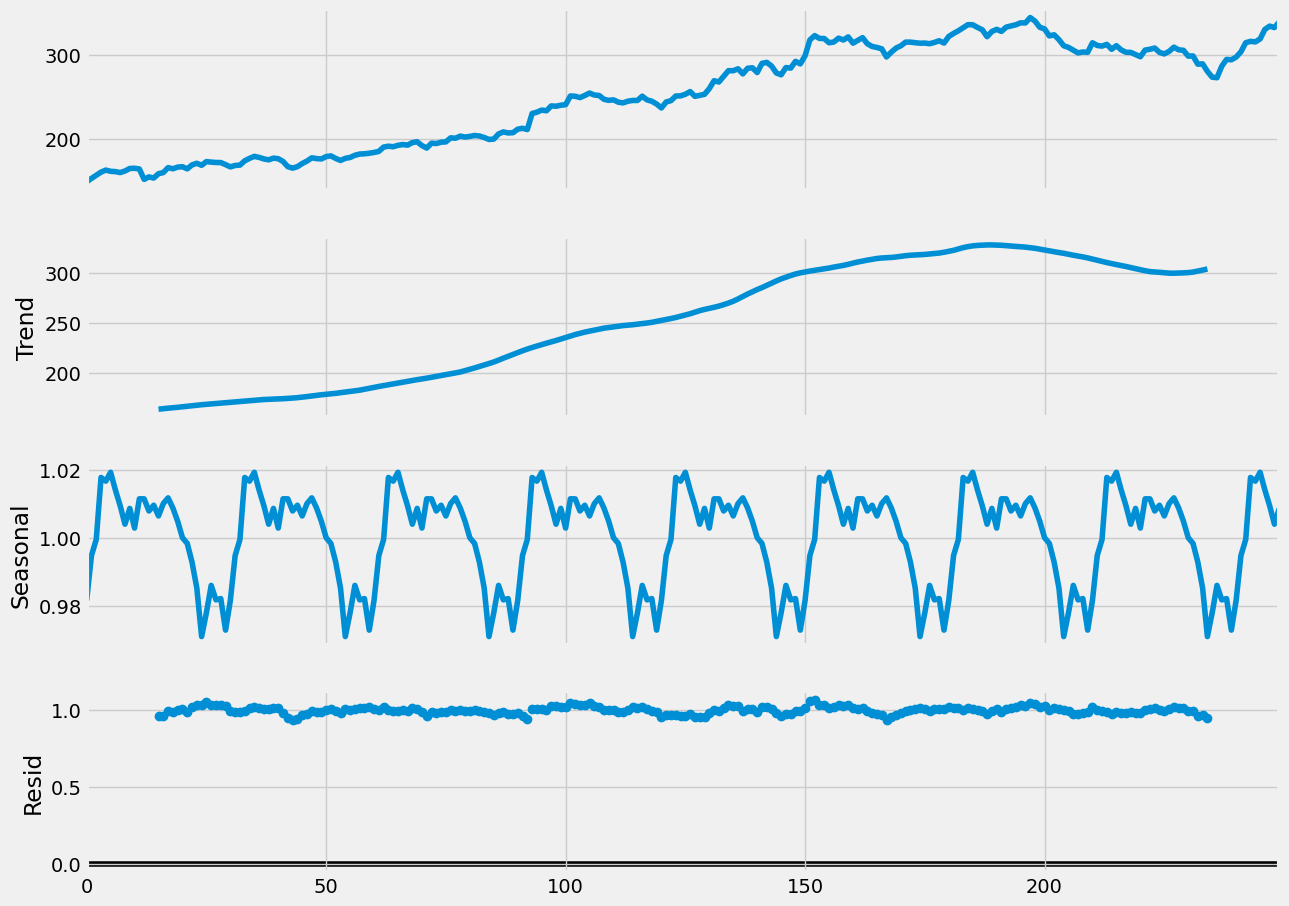

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data["Close"], 
                            model='multiplicative',period = 30)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(15, 10)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

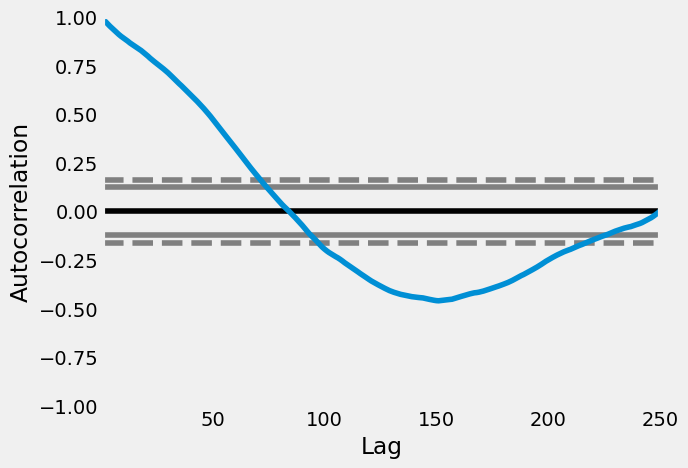

In [7]:
pd.plotting.autocorrelation_plot(data["Close"])

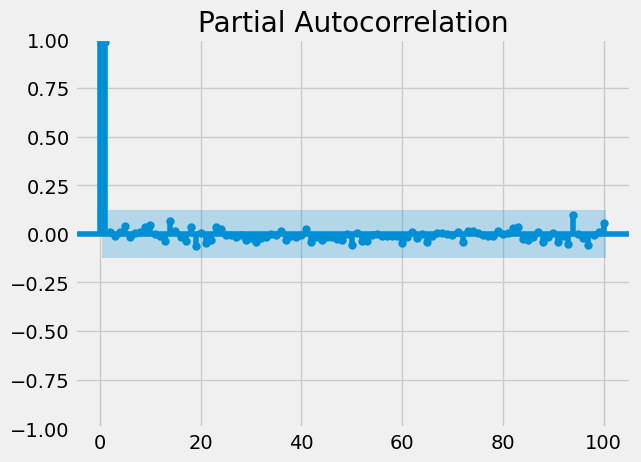

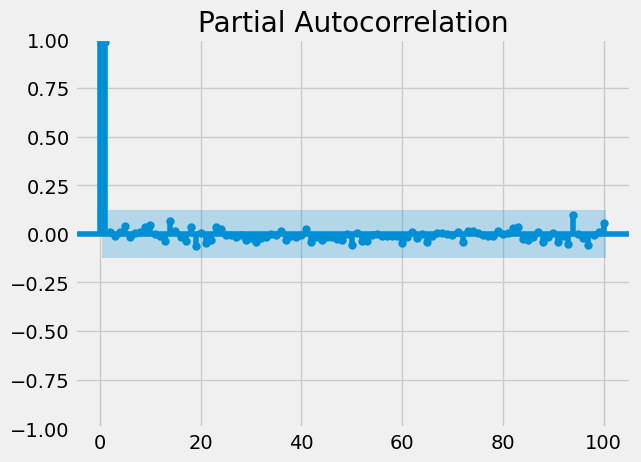

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(data["Close"], lags = 100)

In [9]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# p, d, q değerleri
p, d, q = 5, 1, 2

# Yeni import yolunu kullanarak modeli kuruyoruz
model = ARIMA(data["Close"], order=(p, d, q))

# Yeni versiyonda 'disp' parametresine gerek yoktur
fitted = model.fit()

# Özeti yazdır
print(fitted.summary())

C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   GOOG   No. Observations:                  250
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -721.907
Date:                Sat, 18 Apr 2026   AIC                           1459.814
Time:                        19:44:41   BIC                           1487.954
Sample:                             0   HQIC                          1471.141
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3688      0.257     -1.438      0.150      -0.872       0.134
ar.L2         -0.5100      0.250     -2.039      0.041      -1.000      -0.020
ar.L3          0.1355      0.089      1.530      0.1

In [10]:
predictions = fitted.predict()
print(predictions)

0        0.000000
1      149.344057
2      153.862447
3      157.882441
4      161.758691
          ...    
245    317.431007
246    320.548485
247    332.169309
248    335.323905
249    333.373262
Name: predicted_mean, Length: 250, dtype: float64


In [11]:
# Split data into train and test
train_size = int(len(data) * 0.8)
train, test = data["Close"][0:train_size], data["Close"][train_size:]

In [12]:
import statsmodels.api as sm
import warnings
model=sm.tsa.statespace.SARIMAX(data['Close'],
                                order=(p, d, q),
                                seasonal_order=(p, d, q, 12))
model = ARIMA(train, order=(5,1,2))
fitted = model.fit()

print(fitted.summary())

C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   GOOG   No. Observations:                  200
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -564.456
Date:                Sat, 18 Apr 2026   AIC                           1144.913
Time:                        19:45:59   BIC                           1171.259
Sample:                             0   HQIC                          1155.576
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3908      0.082    -17.053      0.000      -1.551      -1.231
ar.L2         -0.7955      0.125     -6.379      0.000      -1.040      -0.551
ar.L3          0.1563      0.142      1.103      0.2

Now let’s predict the future stock prices using the SARIMA model for the next 10 days:

In [13]:
predictions = fitted.predict(start=len(train), end=len(train)+len(test)-1)
print(predictions)

200    333.019787
201    331.450299
202    332.667538
203    331.451193
204    331.462975
205    332.493254
206    330.844600
207    332.314124
208    331.667367
209    331.210444
210    332.543491
211    330.947642
212    332.083817
213    331.910085
214    331.059743
215    332.534112
216    331.109429
217    331.844644
218    332.117614
219    330.976578
220    332.457636
221    331.308397
222    331.614761
223    332.274507
224    330.961965
225    332.325848
226    331.524801
227    331.412508
228    332.371907
229    331.011409
230    332.154325
231    331.739172
232    331.252423
233    332.406656
234    331.115461
235    331.960652
236    331.933833
237    331.144323
238    332.381078
239    331.260912
240    331.762798
241    332.094218
242    331.092881
243    332.302324
244    331.432206
245    331.577584
246    332.209828
247    331.097661
248    332.181376
249    331.612933
Name: predicted_mean, dtype: float64


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test - predictions) / test)) * 100

print("Model Performance Metrics:")
print(f"MAE  (Mean Absolute Error): {mae}")
print(f"RMSE (Root Mean Squared Error): {rmse}")
print(f"MAPE (Mean Absolute Percentage Error): {mape}")

Model Performance Metrics:
MAE  (Mean Absolute Error): 25.24737054456647
RMSE (Root Mean Squared Error): 28.350905224356897
MAPE (Mean Absolute Percentage Error): nan


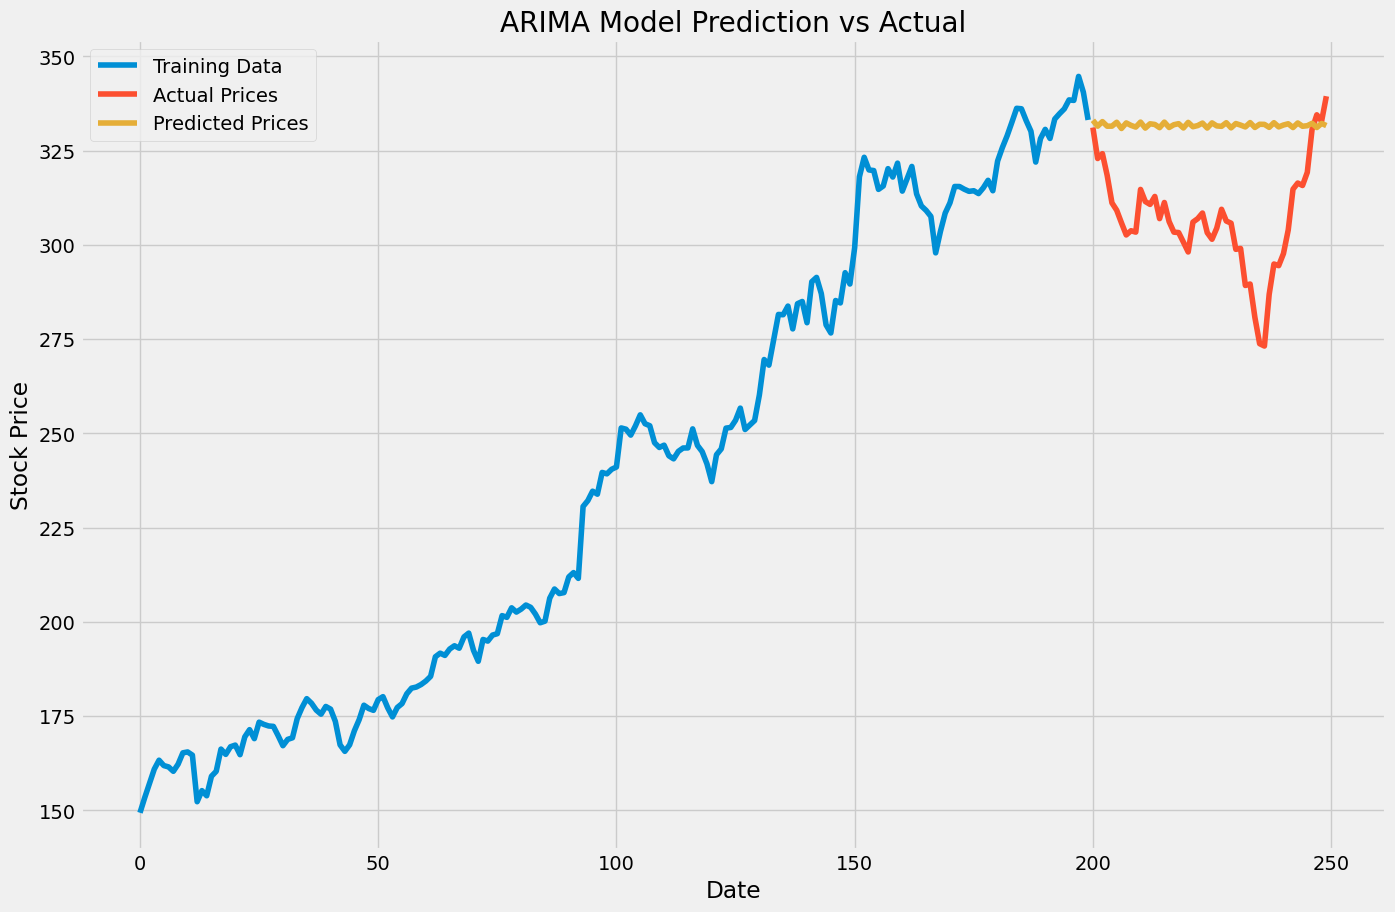

In [16]:
plt.figure(figsize=(15,10))
plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Prices")
plt.plot(predictions, label="Predicted Prices")

plt.title("ARIMA Model Prediction vs Actual")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

## Summary
The ARIMA model provides a reasonable approximation of stock price trends.
However, due to market volatility, prediction accuracy is limited.
More advanced models such as LSTM or hybrid approaches could improve performance.
ARIMA stands for Autoregressive Integrated Moving Average. It is an algorithm used for forecasting Time Series Data. If the data is stationary, we need to use ARIMA, if the data is seasonal, we need to use Seasonal ARIMA (SARIMA). I hope you liked this article about Time Series Forecasting with ARIMA using Python. Feel free to ask valuable questions in the comments section below.